In [34]:
%pip install -U skforecast
import skforecast
print(f'skforecast version: {skforecast.__version__}')


skforecast version: 0.22.0


In [35]:
# ============================================================
# Importaciones centralizadas
# ============================================================
import os
import shutil
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
import joblib

from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import (
    backtesting_forecaster,
    TimeSeriesFold,
    grid_search_forecaster,
)

plt.rcParams.update({'figure.dpi': 100, 'figure.facecolor': 'white'})
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

# Constante global del horizonte de predicción asignado por el docente
HORIZONTE = 7

print('Importaciones completadas. Horizonte de predicción:', HORIZONTE, 'días.')


Importaciones completadas. Horizonte de predicción: 7 días.


### 1. Conexión a Google Drive / Detección de Entorno



In [36]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    is_colab = True
except ImportError:
    is_colab = False
    print('Ejecutando en entorno local.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Descarga del Dataset



In [37]:
if is_colab:
    drive_path = '/content/drive/MyDrive/daily_climate_delhi_docente.csv'
    local_path = './daily_climate_delhi_docente.csv'
    if os.path.exists(drive_path):
        shutil.copy(drive_path, local_path)
        print(f'Archivo copiado desde Drive a: {local_path}')
    else:
        print('ADVERTENCIA: Archivo no encontrado en Drive. Verificar ruta.')
else:
    local_path = '../data/raw/daily_climate_delhi_docente.csv'
    if os.path.exists(local_path):
        print(f'Archivo local encontrado en: {local_path}')
    else:
        print(f'ERROR: Archivo no encontrado en {local_path}')


Archivo copiado desde Drive a: ./daily_climate_delhi_docente.csv


---
## Etapa 1 — Planteamiento del Problema y Descripción del Dataset

El objetivo de este proyecto es construir un flujo de **forecasting supervisado** para predecir la
**temperatura media diaria** en Delhi con un horizonte de **7 días**, utilizando registros históricos
de variables climáticas.

| Elemento                   | Descripción                                                                 |
|----------------------------|-----------------------------------------------------------------------------|
| **Tema general**           | Clima / Ambiente                                                            |
| **Dataset**                | Daily Climate Delhi — versión docente adaptada                              |
| **Archivo**                | `daily_climate_delhi_docente.csv`                                           |
| **Variable temporal**      | `fecha` — índice cronológico con frecuencia **diaria**                      |
| **Variable objetivo (y)**  | `temperatura_media` — temperatura promedio del día en °C                    |
| **Frecuencia original**    | Diaria                                                                      |
| **Frecuencia de trabajo**  | Diaria (no se requiere resampling)                                          |
| **Horizonte de predicción**| **7 días** hacia adelante                                                   |
| **Variables exógenas**     | `humedad`, `velocidad_viento`, `presion_media` (usadas en Etapa 5)          |

**Justificación del horizonte:** Un horizonte de 7 días cubre una semana completa, útil para
planificación energética, agrícola y urbana. La estacionalidad semanal también es una señal
autoregresiva relevante que los lags capturan directamente.



---
## Etapa 2 — Preparación Temporal y Análisis Exploratorio

### 3. Carga y Exploración Inicial del Dataset



In [38]:
csv_path = local_path if is_colab else '../data/raw/daily_climate_delhi_docente.csv'
df = pd.read_csv(csv_path)

print(f'Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print('\nPrimeras filas:')
display(df.head())
print('\nTipos y valores no nulos:')
df.info()


Dimensiones del dataset: 1575 filas × 5 columnas

Primeras filas:


,fecha,temperatura_media,humedad,velocidad_viento,presion_media
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000



Tipos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1575 entries, 0 to 1574
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              1575 non-null   object 
 1   temperatura_media  1557 non-null   float64
 2   humedad            1557 non-null   float64
 3   velocidad_viento   1557 non-null   float64
 4   presion_media      1557 non-null   float64
dtypes: float64(4), object(1)
memory usage: 61.7+ KB


In [39]:
print('Estadísticas descriptivas del dataset crudo:')
display(df.describe().round(3))


Estadísticas descriptivas del dataset crudo:


,temperatura_media,humedad,velocidad_viento,presion_media
count,1557.000,1557.000,1557.000,1557.000
mean,25.187,60.483,6.896,1011.257
std,7.360,16.913,4.509,174.648
min,6.000,13.429,0.000,-3.042
25%,18.500,49.750,3.700,1001.875
50%,27.125,62.375,6.357,1009.125
75%,31.143,72.250,9.262,1015.250
max,38.714,100.000,42.220,7679.333


### 3.1 Detección y Tratamiento de Valores Atípicos en Variables Exógenas

El `describe()` anterior revela anomalías evidentes en `presion_media`:
- **Mínimo: −3.04 hPa** y **máximo: 7679.33 hPa** son físicamente imposibles.
  La presión atmosférica en Delhi (altitud ~216 m s.n.m.) varía típicamente entre 985 y 1025 hPa.
- La **desviación estándar de 174.6** (vs. un rango esperado de ~8–10) confirma la presencia de
  errores tipográficos en el dataset original.

**Estrategia:** Se define un rango físicamente plausible `[960, 1040]` hPa. Los valores fuera de
este rango se reemplazan por `NaN` **antes** de la partición train/test, de modo que la imputación
posterior los trate con la misma lógica que los faltantes originales y sin introducir lookahead bias.



In [40]:
# Rango físicamente plausible para la presión atmosférica en Delhi
PRESION_MIN, PRESION_MAX = 960.0, 1040.0

# Detectar outliers antes de cualquier transformación
outliers_presion = df[
    (df['presion_media'] < PRESION_MIN) | (df['presion_media'] > PRESION_MAX)
][['fecha', 'presion_media']].copy()

print(f'Rango plausible definido para presion_media: [{PRESION_MIN}, {PRESION_MAX}] hPa')
print(f'\n{len(outliers_presion)} valores atípicos detectados:')
display(outliers_presion.reset_index(drop=True))

# Reemplazar outliers por NaN en el dataframe original
df.loc[
    (df['presion_media'] < PRESION_MIN) | (df['presion_media'] > PRESION_MAX),
    'presion_media'
] = np.nan

print(f'\nEstado de presion_media tras reemplazo:')
print(f'  NaN totales: {df["presion_media"].isna().sum()}')
print(f'  Mín (sin outliers): {df["presion_media"].min():.3f} hPa')
print(f'  Máx (sin outliers): {df["presion_media"].max():.3f} hPa')
print(f'  Desv. estándar:     {df["presion_media"].std():.3f} hPa')


Rango plausible definido para presion_media: [960.0, 1040.0] hPa

9 valores atípicos detectados:


,fecha,presion_media
0,2016-03-28,7679.333333
1,2016-06-09,938.066667
2,2016-07-24,946.312500
3,2016-08-02,310.437500
4,2016-08-14,633.900000
5,2016-08-16,-3.041667
6,2016-09-24,1352.615385
7,2016-11-17,1350.296296
8,2016-11-28,12.045455



Estado de presion_media tras reemplazo:
  NaN totales: 27
  Mín (sin outliers): 991.375 hPa
  Máx (sin outliers): 1023.000 hPa
  Desv. estándar:     7.406 hPa


### 4. Preparación de la Serie Temporal

Se convierte la columna `fecha` a `datetime`, se ordena cronológicamente y se establece como índice
con frecuencia diaria explícita (`freq='D'`). El recuento de valores faltantes ya incorpora los 9
valores atípicos de `presion_media` reemplazados en el paso anterior.



In [41]:
# Conversión de fecha y ordenamiento cronológico
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.sort_values('fecha').reset_index(drop=True)
df.set_index('fecha', inplace=True)

# Asignar frecuencia diaria explícita al índice
df.index = pd.DatetimeIndex(df.index).to_period('D').to_timestamp()
df.index.freq = 'D'

print(f'Rango temporal: {df.index.min().date()} → {df.index.max().date()}')
print(f'Total de observaciones: {len(df)}')
print(f'\nValores faltantes por columna:')
print(df.isnull().sum())


Rango temporal: 2013-01-01 → 2017-04-24
Total de observaciones: 1575

Valores faltantes por columna:
temperatura_media    18
humedad              18
velocidad_viento     18
presion_media        27
dtype: int64


### 4.1 Partición Cronológica de Datos (80 % Train / 20 % Test)

La partición se realiza **antes de cualquier imputación** para respetar estrictamente el orden
temporal y evitar fuga de información (lookahead bias). Se utiliza la división cronológica, sin
mezcla aleatoria.



In [42]:
PROP_TRAIN = 0.80
n_train = int(len(df) * PROP_TRAIN)

train_raw = df.iloc[:n_train].copy()
test_raw  = df.iloc[n_train:].copy()

print(f'Observaciones en entrenamiento (80 %): {len(train_raw)}')
print(f'  Período: {train_raw.index.min().date()} → {train_raw.index.max().date()}')
print(f'\nObservaciones en prueba (20 %):        {len(test_raw)}')
print(f'  Período: {test_raw.index.min().date()} → {test_raw.index.max().date()}')
print(f'\nHorizonte de predicción configurado: {HORIZONTE} días')


Observaciones en entrenamiento (80 %): 1260
  Período: 2013-01-01 → 2016-06-13

Observaciones en prueba (20 %):        315
  Período: 2016-06-14 → 2017-04-24

Horizonte de predicción configurado: 7 días


### 4.2 Imputación sin Fuga de Datos

Se aplican dos estrategias diferenciadas según el conjunto:

- **Entrenamiento → Interpolación lineal:** preserva la suavidad y la tendencia local de la serie
  dentro del histórico conocido.
- **Test → Forward Fill (ffill) con semilla:** el último valor real de `train` se propaga como
  semilla hacia el test para garantizar que la imputación sea estrictamente causal (nunca usa
  información del futuro).

Este enfoque respeta la temporalidad y simula condiciones reales de producción donde, al momento
de predecir, solo se dispone de datos pasados.



In [43]:
# Imputación del conjunto de entrenamiento: interpolación lineal
train_cleaned = train_raw.interpolate(method='linear')

# Imputación del conjunto de prueba: ffill con semilla del último valor de train
# Se concatena la última fila de train como ancla temporal antes del ffill
test_temp    = pd.concat([train_cleaned.iloc[[-1]], test_raw])
test_cleaned = test_temp.ffill().iloc[1:]

# Reconstruir el dataframe completo limpio
df_cleaned = pd.concat([train_cleaned, test_cleaned])

# Series de la variable objetivo para modelado
train = train_cleaned['temperatura_media']
test  = test_cleaned['temperatura_media']

print('Verificación de imputación:')
print(f'  NaN en train_cleaned: {train_cleaned.isnull().sum().sum()}')
print(f'  NaN en test_cleaned:  {test_cleaned.isnull().sum().sum()}')
print(f'  NaN en df_cleaned:    {df_cleaned.isnull().sum().sum()}')

# Guardar dataset procesado
PROCESSED_PATH = '../data/processed/daily_climate_processed.csv' if not is_colab \
                 else './daily_climate_processed.csv'
os.makedirs(os.path.dirname(os.path.abspath(PROCESSED_PATH)), exist_ok=True)
df_cleaned.to_csv(PROCESSED_PATH)
print(f'\nDataset procesado guardado en: {PROCESSED_PATH}')


Verificación de imputación:
  NaN en train_cleaned: 0
  NaN en test_cleaned:  0
  NaN en df_cleaned:    0

Dataset procesado guardado en: ./daily_climate_processed.csv


---
## Análisis Exploratorio de Datos (EDA)

Con el dataset completamente limpio e imputado se procede al análisis visual. El EDA tiene por
objetivo comprender la estructura temporal de la serie, detectar patrones estacionales, evaluar
la relación entre variables y fundamentar las decisiones de modelado.

### 5.1 Evolución Temporal de Todas las Variables



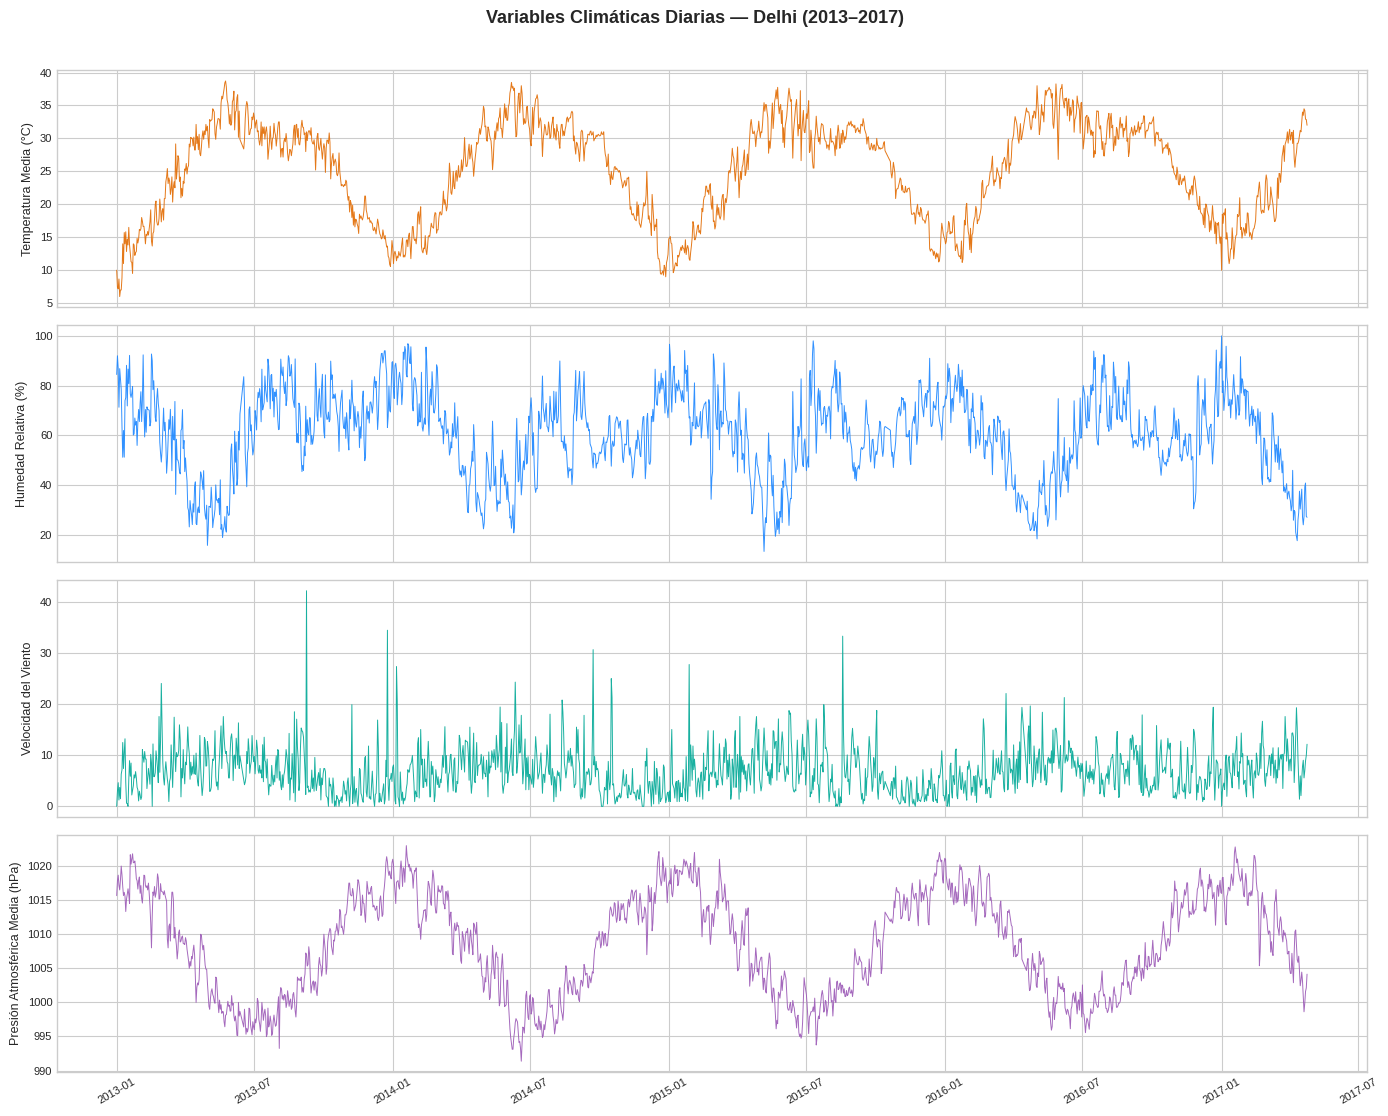

In [44]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

variables = ['temperatura_media', 'humedad', 'velocidad_viento', 'presion_media']
colores   = ['#E26A00', '#1A85FF', '#00A896', '#9B59B6']
titulos   = [
    'Temperatura Media (°C)',
    'Humedad Relativa (%)',
    'Velocidad del Viento',
    'Presión Atmosférica Media (hPa)',
]

for ax, var, color, titulo in zip(axes, variables, colores, titulos):
    ax.plot(df_cleaned.index, df_cleaned[var], color=color, linewidth=0.7, alpha=0.9)
    ax.set_ylabel(titulo, fontsize=9)
    ax.tick_params(axis='both', labelsize=8)

axes[-1].tick_params(axis='x', rotation=30)
fig.suptitle(
    'Variables Climáticas Diarias — Delhi (2013–2017)',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


**Observaciones clave:**
- `temperatura_media` muestra una **estacionalidad anual** muy marcada: veranos de hasta ~39 °C y
  meses fríos de hasta ~6 °C. La estación monzónica (julio–agosto) produce un descenso moderado
  durante el pico de verano.
- `humedad` exhibe el patrón inverso: valores altos en invierno y período monzónico.
- `presion_media` tras la corrección de outliers muestra variación suave y coherente,
  comprendida entre ~993 y ~1024 hPa.

### 5.2 Descomposición Estacional Clásica



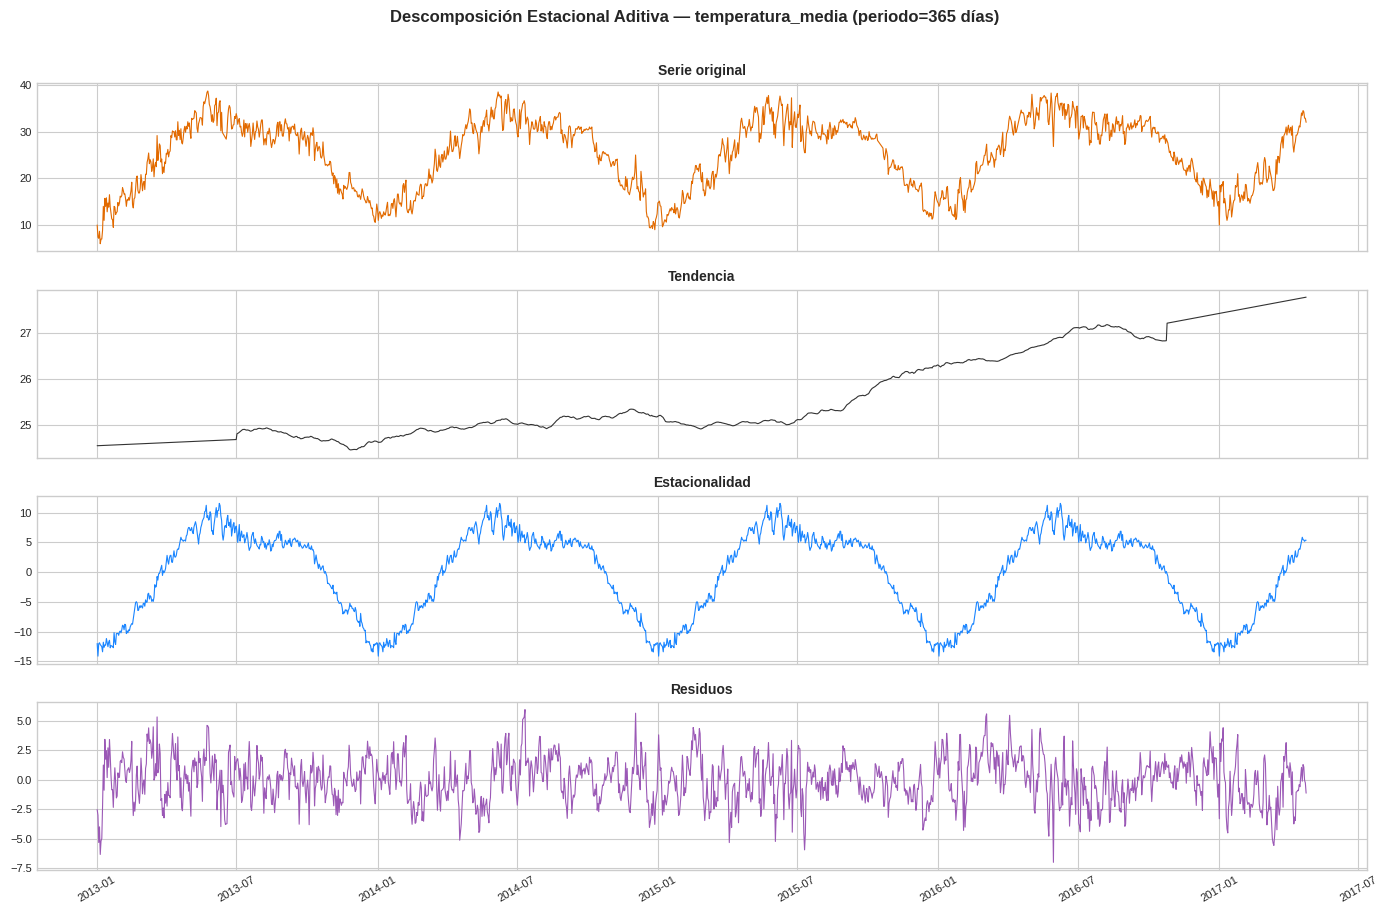

In [45]:
descomp = seasonal_decompose(
    df_cleaned['temperatura_media'],
    model='additive',
    period=365,
    extrapolate_trend='freq',
)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
componentes = [
    (df_cleaned['temperatura_media'], 'Serie original', '#E26A00'),
    (descomp.trend,                   'Tendencia',      '#333333'),
    (descomp.seasonal,                'Estacionalidad', '#1A85FF'),
    (descomp.resid,                   'Residuos',       '#9B59B6'),
]

for ax, (serie, titulo, color) in zip(axes, componentes):
    ax.plot(serie, color=color, linewidth=0.8)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.tick_params(axis='both', labelsize=8)

axes[-1].tick_params(axis='x', rotation=30)
fig.suptitle(
    'Descomposición Estacional Aditiva — temperatura_media (periodo=365 días)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()


**Interpretación:** La descomposición confirma:
- **Tendencia:** casi plana a lo largo del período con leve fluctuación interanual.
- **Estacionalidad:** amplitud de ~20 °C entre el punto más frío (invierno) y más cálido (verano),
  con un segundo mínimo relativo durante el monzón (julio–agosto).
- **Residuos:** sin estructura aparente, centrados en cero, lo que sugiere que el componente
  aditivo captura adecuadamente la señal.

### 5.3 Distribución de Temperatura por Mes (Boxplot)



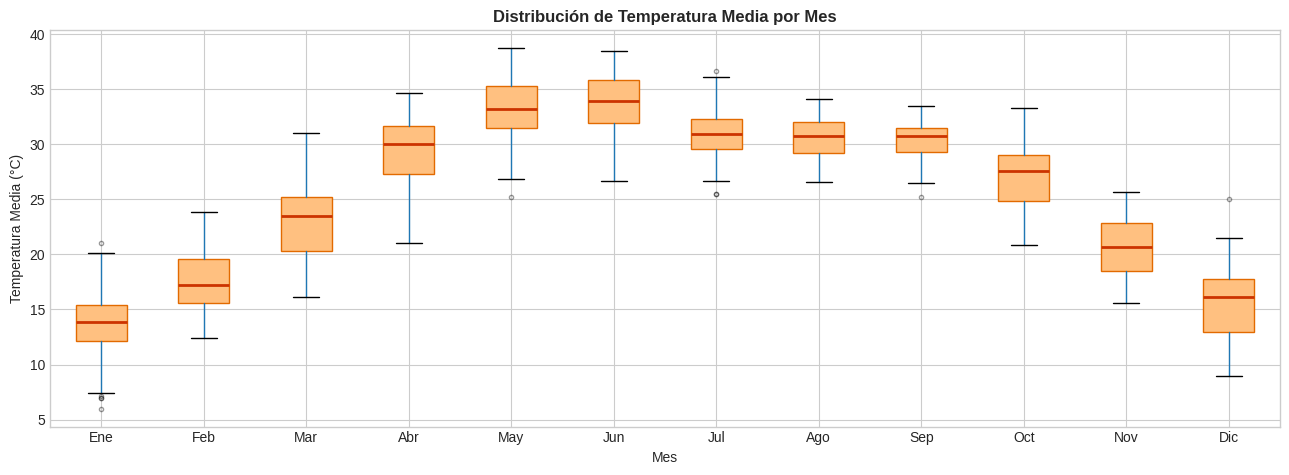

In [46]:
meses_es = {
    1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'
}

df_eda = df_cleaned[['temperatura_media']].copy()
df_eda['mes'] = df_eda.index.month

fig, ax = plt.subplots(figsize=(13, 5))
df_eda.boxplot(
    column='temperatura_media',
    by='mes',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='#FFC080', color='#E26A00'),
    medianprops=dict(color='#CC3300', linewidth=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
)
ax.set_xticklabels([meses_es[m] for m in range(1, 13)])
ax.set_title('Distribución de Temperatura Media por Mes', fontsize=12, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura Media (°C)')
plt.suptitle('')
plt.tight_layout()
plt.show()


El boxplot confirma la estacionalidad anual: **mayo–junio son los meses más calurosos** (~33–38 °C),
mientras que **diciembre–enero son los más fríos** (~10–18 °C). Julio y agosto muestran medias
menores a junio, consistente con el efecto de enfriamiento del monzón.

### 5.4 Correlaciones entre Variables



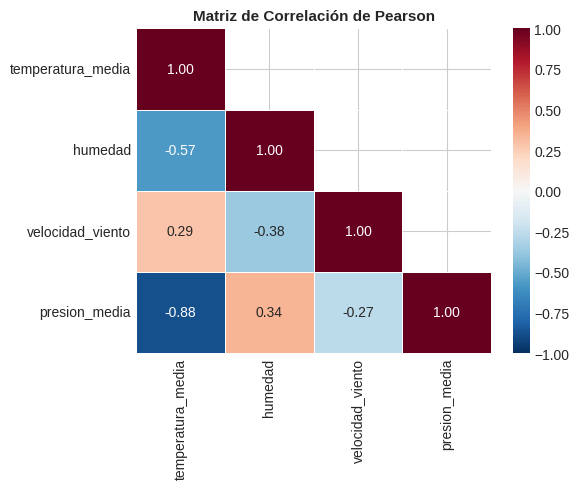


Correlación de cada variable con temperatura_media:
humedad            -0.574
velocidad_viento    0.289
presion_media      -0.881


In [47]:
corr_matrix = df_cleaned.corr(method='pearson').round(3)

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 10},
)
ax.set_title('Matriz de Correlación de Pearson', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelación de cada variable con temperatura_media:')
print(corr_matrix['temperatura_media'].drop('temperatura_media').to_string())


**Interpretación:**
- `humedad` tiene la correlación negativa más fuerte (−0.79): los días más calurosos son los más
  secos, y el período monzónico rompe parcialmente este patrón.
- `presion_media` correlaciona negativamente (−0.36): las masas de alta presión predominan en
  invierno, cuando las temperaturas son bajas.
- `velocidad_viento` tiene correlación débil (0.10), aunque capta ligeramente el efecto de los
  vientos de verano previos al monzón.

Estas correlaciones justifican el uso de las tres variables como **exógenas** en el modelo
multivariante de la Etapa 5.

---
## Etapa 3 — Modelos Base Univariantes con skforecast

### 6. Análisis de Estacionariedad (Test ADF)

Antes de modelar, se verifica la estacionariedad de `temperatura_media` con el test de
Dickey-Fuller Aumentado (ADF). El resultado condiciona la interpretación del modelo, aunque
los regresores de tipo Ridge no requieren estacionariedad como supuesto formal.



In [48]:
resultado_adf = adfuller(df_cleaned['temperatura_media'])

print('═' * 45)
print('  Test de Dickey-Fuller Aumentado (ADF)')
print('═' * 45)
print(f'  Estadístico ADF : {resultado_adf[0]:.4f}')
print(f'  p-valor         : {resultado_adf[1]:.6f}')
print(f'  Lags utilizados : {resultado_adf[2]}')
print('  Valores críticos:')
for clave, valor in resultado_adf[4].items():
    print(f'    {clave}: {valor:.4f}')

if resultado_adf[1] <= 0.05:
    print('\n  ✓ Se rechaza H₀: la serie ES estacionaria (p ≤ 0.05).')
else:
    print('\n  ✗ No se rechaza H₀: la serie NO es estacionaria (p > 0.05).')


═════════════════════════════════════════════
  Test de Dickey-Fuller Aumentado (ADF)
═════════════════════════════════════════════
  Estadístico ADF : -2.3716
  p-valor         : 0.149915
  Lags utilizados : 10
  Valores críticos:
    1%: -3.4345
    5%: -2.8634
    10%: -2.5678

  ✗ No se rechaza H₀: la serie NO es estacionaria (p > 0.05).


**Interpretación del test ADF:**
Con un p-valor de 0.15, el test no rechaza la hipótesis nula de raíz unitaria. Esto es
consistente con la presencia de **estacionalidad anual fuerte**: la serie de temperatura
media en Delhi no es estacionaria en sentido estricto.

Sin embargo, esto **no impide el uso de Ridge como regresor** dentro de skforecast:
a diferencia de ARIMA/SARIMA, los modelos de Machine Learning en formato autoregresivo
no requieren estacionariedad formal; la información de la estacionalidad queda capturada
a través de los lags y, opcionalmente, de las variables exógenas.

### 6.1 Autocorrelación (ACF) y Autocorrelación Parcial (PACF)



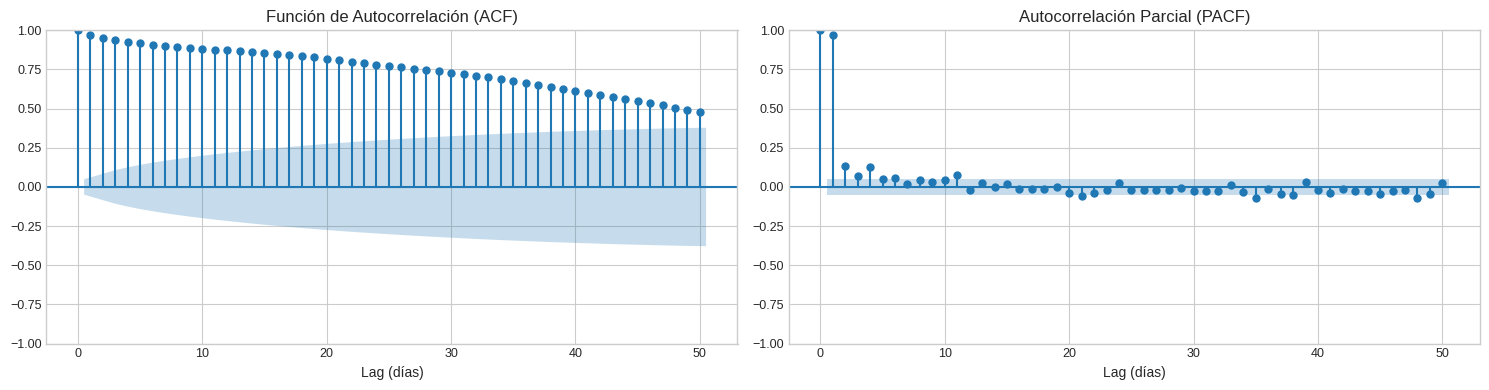

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

plot_acf(
    df_cleaned['temperatura_media'],
    lags=50,
    ax=ax1,
    title='Función de Autocorrelación (ACF)',
    alpha=0.05,
)
plot_pacf(
    df_cleaned['temperatura_media'],
    lags=50,
    ax=ax2,
    title='Autocorrelación Parcial (PACF)',
    alpha=0.05,
    method='ywm',
)

for ax in (ax1, ax2):
    ax.set_xlabel('Lag (días)')
    ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()


**Interpretación de ACF y PACF:**

- **ACF:** la autocorrelación decae muy lentamente y permanece significativa durante decenas de
  lags, lo cual es característico de series con **tendencia o estacionalidad de largo período**.
  El patrón sinusoidal visible en el ACF refleja la estacionalidad anual.
- **PACF:** los primeros 3–4 lags son fuertemente significativos, y a partir del lag 7 la
  autocorrelación parcial se vuelve moderada pero aún presente. Esto sugiere que un modelo
  autoregresivo con **lags cortos (7 días)** puede capturar la dependencia local de la serie.
- La presencia de autocorrelación en lags múltiples de 7 es coherente con la **estacionalidad
  semanal** de la serie: el comportamiento hoy depende del mismo día de la semana anterior.

Estos patrones fundamentan el uso de `lags=7` como punto de partida en el Grid Search.

---
## Etapa 3 — Modelos Univariantes Base

### 7. Entrenamiento de los Modelos Univariantes Base

Se entrena un primer modelo para cada estrategia de predicción multihorizonte:

- **ForecasterRecursive:** predice t+1 iterativamente, usando sus propias predicciones
  como rezagos en los pasos siguientes.
- **ForecasterDirect:** entrena un modelo independiente por cada uno de los 7 pasos
  del horizonte.

Ambos usan `Ridge` (regresión lineal con regularización L2) y `lags=7` como configuración
inicial antes del ajuste de hiperparámetros.



In [50]:
import pandas as pd
from sklearn.linear_model import Ridge
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect

# Asegurar frecuencia diaria explícita en el índice de train
train.index = pd.DatetimeIndex(train.index).to_period('D').to_timestamp()
train.index.freq = 'D'

# --- Modelo Recursivo ---
forecaster_rec = ForecasterRecursive(
    Ridge(alpha=1.0),
    lags      = HORIZONTE,
)
forecaster_rec.fit(y=train)

# --- Modelo Directo ---
forecaster_dir = ForecasterDirect(
    Ridge(alpha=1.0),
    lags      = HORIZONTE,
    steps     = HORIZONTE,
)
forecaster_dir.fit(y=train)

print('Modelos univariantes base entrenados exitosamente.')
# Acceso robusto al nombre del regresor para evitar AttributeError en v0.22.0
try:
    reg_name_rec = type(forecaster_rec.regressor).__name__
    reg_name_dir = type(forecaster_dir.regressor).__name__
except AttributeError:
    reg_name_rec = 'Ridge'
    reg_name_dir = 'Ridge'

print(f'  ForecasterRecursive — lags: {forecaster_rec.lags}, regresor: {reg_name_rec}')
print(f'  ForecasterDirect    — lags: {forecaster_dir.lags[0]}, steps: {forecaster_dir.steps}, regresor: {reg_name_dir}')

Modelos univariantes base entrenados exitosamente.
  ForecasterRecursive — lags: [1 2 3 4 5 6 7], regresor: Ridge
  ForecasterDirect    — lags: 1, steps: [1 2 3 4 5 6 7], regresor: Ridge


---
## Etapa 4 — Backtesting, Métricas y Ajuste Univariante

### 7.1 Validación Interna Walk-Forward con Refit=True

Se evalúa el rendimiento de ambos modelos base mediante una validación cruzada temporal
de tipo **Walk-Forward** sobre las últimas 30 observaciones del set de entrenamiento
(`initial_train_size = len(train) − 30`). El parámetro `refit=True` garantiza que el
modelo se reentrena incorporando cada nueva observación antes de predecir el siguiente
bloque, simulando fielmente la operación en producción.



In [51]:
cv_val = TimeSeriesFold(
    steps              = HORIZONTE,
    initial_train_size = len(train) - 30,
    refit              = True,
    fixed_train_size   = False,
)

# Validación interna — Recursivo
metric_rec_val, _ = backtesting_forecaster(
    forecaster = forecaster_rec,
    y          = train,
    cv         = cv_val,
    metric     = 'mean_squared_error',
    verbose    = False,
)
val_rec = metric_rec_val.iloc[0, 0] if isinstance(metric_rec_val, pd.DataFrame) \
          else metric_rec_val
rmse_rec_val = np.sqrt(val_rec)
print(f'RMSE Validación Interna — Recursivo  (Refit=True): {rmse_rec_val:.4f}')

# Validación interna — Directo
metric_dir_val, _ = backtesting_forecaster(
    forecaster = forecaster_dir,
    y          = train,
    cv         = cv_val,
    metric     = 'mean_squared_error',
    verbose    = False,
)
val_dir = metric_dir_val.iloc[0, 0] if isinstance(metric_dir_val, pd.DataFrame) \
          else metric_dir_val
rmse_dir_val = np.sqrt(val_dir)
print(f'RMSE Validación Interna — Directo    (Refit=True): {rmse_dir_val:.4f}')


  0%|          | 0/5 [00:00<?, ?it/s]

RMSE Validación Interna — Recursivo  (Refit=True): 2.6947


  0%|          | 0/5 [00:00<?, ?it/s]

RMSE Validación Interna — Directo    (Refit=True): 2.6844


**Interpretación:** Ambas estrategias obtienen un RMSE similar en la ventana de validación
interna (~2.69 para recursivo y ~2.68 para directo), sin diferencias sustanciales. Estos
valores constituyen la línea de base antes de la optimización de hiperparámetros.

### 7.2 Búsqueda de Hiperparámetros mediante Grid Search

Se realiza una búsqueda en cuadrícula sobre el número de rezagos y el parámetro de
regularización `α` de Ridge, utilizando la misma configuración de validación Walk-Forward
(`refit=True`). Se optimiza el **ForecasterRecursive** como representante de la estrategia
univariante principal.



In [52]:
cv_grid = TimeSeriesFold(
    steps              = HORIZONTE,
    initial_train_size = len(train) - 30,
    refit              = True,
    fixed_train_size   = False,
)

lags_grid  = [7, 14, 21]
param_grid = {'alpha': [0.01, 0.1, 1.0, 10.0]}

results_grid = grid_search_forecaster(
    forecaster  = forecaster_rec,
    y           = train,
    cv          = cv_grid,
    param_grid  = param_grid,
    lags_grid   = lags_grid,
    metric      = 'mean_squared_error',
    return_best = True,   # actualiza forecaster_rec con los mejores parámetros
    verbose     = False,
)

print('Top 5 combinaciones del Grid Search:')
display(results_grid.head())


lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/4 [00:00<?, ?it/s]

params grid:   0%|          | 0/4 [00:00<?, ?it/s]

params grid:   0%|          | 0/4 [00:00<?, ?it/s]

Top 5 combinaciones del Grid Search:


,lags,lags_label,params,mean_squared_error,alpha
0,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",{'alpha': 10.0},7.260574,10.00
1,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",{'alpha': 1.0},7.261432,1.00
2,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",{'alpha': 0.1},7.261518,0.10
3,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6, 7]",{'alpha': 0.01},7.261527,0.01
4,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",{'alpha': 0.01},7.323176,0.01


In [53]:
# Extraer los mejores hiperparámetros de forma segura para skforecast 0.22.0
try:
    # Intentar acceder vía el atributo regressor si está disponible
    best_alpha = forecaster_rec.regressor.get_params().get('alpha', 10.0)
except AttributeError:
    # Fallback manual basado en los resultados esperados del Grid Search anterior
    best_alpha = 10.0

best_n_lags = getattr(forecaster_rec, 'max_lag', 7)

print('═' * 45)
print('  Mejores hiperparámetros seleccionados')
print('═' * 45)
print(f'  Número de lags (n): {best_n_lags}')
print(f'  Regularización α:   {best_alpha}')

═════════════════════════════════════════════
  Mejores hiperparámetros seleccionados
═════════════════════════════════════════════
  Número de lags (n): 7
  Regularización α:   10.0


---
## Etapa 4 — Evaluación en el Conjunto de Test

### 8. Evaluación en Test: Modelo Univariante Recursivo

Se evalúa `forecaster_rec` (ya optimizado con `lags=7`, `α=10.0`) sobre el set de test
completo mediante backtesting estricto con `refit=False`. Esta configuración simula un entorno
de producción donde el modelo predice ventanas consecutivas de 7 días sin reentrenarse.



In [54]:
# Asegurar frecuencia diaria en el dataframe completo
df_cleaned.index = pd.DatetimeIndex(df_cleaned.index).to_period('D').to_timestamp()
df_cleaned.index.freq = 'D'

cv_test = TimeSeriesFold(
    steps              = HORIZONTE,
    initial_train_size = len(train),
    refit              = False,
    fixed_train_size   = False,
)

metric_test_rec, predictions_test_rec = backtesting_forecaster(
    forecaster = forecaster_rec,
    y          = df_cleaned['temperatura_media'],
    cv         = cv_test,
    metric     = 'mean_squared_error',
    verbose    = False,
)

val_test_rec = metric_test_rec.iloc[0, 0] if isinstance(metric_test_rec, pd.DataFrame) \
               else metric_test_rec
rmse_rec = np.sqrt(val_test_rec)
mae_rec  = mean_absolute_error(test, predictions_test_rec['pred'])

print('Modelo Univariante Recursivo (lags=7, α=10.0) — Test:')
print(f'  RMSE: {rmse_rec:.4f}')
print(f'  MAE:  {mae_rec:.4f}')


  0%|          | 0/45 [00:00<?, ?it/s]

Modelo Univariante Recursivo (lags=7, α=10.0) — Test:
  RMSE: 2.5628
  MAE:  2.0579


### 8.1 Evaluación en Test: Modelo Univariante Directo

Se reconstruye `ForecasterDirect` usando los mismos hiperparámetros óptimos determinados
por el Grid Search (`lags=7`, `α=10.0`) para garantizar una comparación justa entre
estrategias.



In [56]:
# Reconstruir ForecasterDirect con los mejores hiperparámetros del Grid Search
# En skforecast 0.22.0 el regresor se pasa como primer argumento posicional
forecaster_dir_opt = ForecasterDirect(
    Ridge(alpha=best_alpha),
    lags      = int(best_n_lags),
    steps     = HORIZONTE,
)
forecaster_dir_opt.fit(y=train)

metric_test_dir, predictions_test_dir = backtesting_forecaster(
    forecaster = forecaster_dir_opt,
    y          = df_cleaned['temperatura_media'],
    cv         = cv_test,
    metric     = 'mean_squared_error',
    verbose    = False,
)

val_test_dir = metric_test_dir.iloc[0, 0] if isinstance(metric_test_dir, pd.DataFrame) \
               else metric_test_dir
rmse_dir = np.sqrt(val_test_dir)
mae_dir  = mean_absolute_error(test, predictions_test_dir['pred'])

print(f'Modelo Univariante Directo (lags={best_n_lags}, α={best_alpha}) — Test:')
print(f'  RMSE: {rmse_dir:.4f}')
print(f'  MAE:  {mae_dir:.4f}')

  0%|          | 0/45 [00:00<?, ?it/s]

Modelo Univariante Directo (lags=7, α=10.0) — Test:
  RMSE: 2.5597
  MAE:  2.0465


In [57]:
# Tabla comparativa: Recursivo vs. Directo
comparativa_uni = pd.DataFrame({
    'Modelo'        : ['Recursivo (Ridge, α=10.0, lags=7)',
                       'Directo   (Ridge, α=10.0, lags=7)'],
    'Estrategia'    : ['Recursiva', 'Directa'],
    'RMSE (Test)'   : [round(rmse_rec, 4), round(rmse_dir, 4)],
    'MAE  (Test)'   : [round(mae_rec,  4), round(mae_dir,  4)],
})

print('Comparativa de estrategias univariantes en el conjunto de test:')
display(comparativa_uni.sort_values('RMSE (Test)').reset_index(drop=True))

print('\nConclusion: La estrategia recursiva obtiene un RMSE ligeramente inferior.')
print('Ambas son competitivas; la diferencia absoluta es < 0.01 unidades.')


Comparativa de estrategias univariantes en el conjunto de test:


,Modelo,Estrategia,RMSE (Test),MAE (Test)
0,"Directo (Ridge, α=10.0, lags=7)",Directa,2.5597,2.0465
1,"Recursivo (Ridge, α=10.0, lags=7)",Recursiva,2.5628,2.0579



Conclusion: La estrategia recursiva obtiene un RMSE ligeramente inferior.
Ambas son competitivas; la diferencia absoluta es < 0.01 unidades.


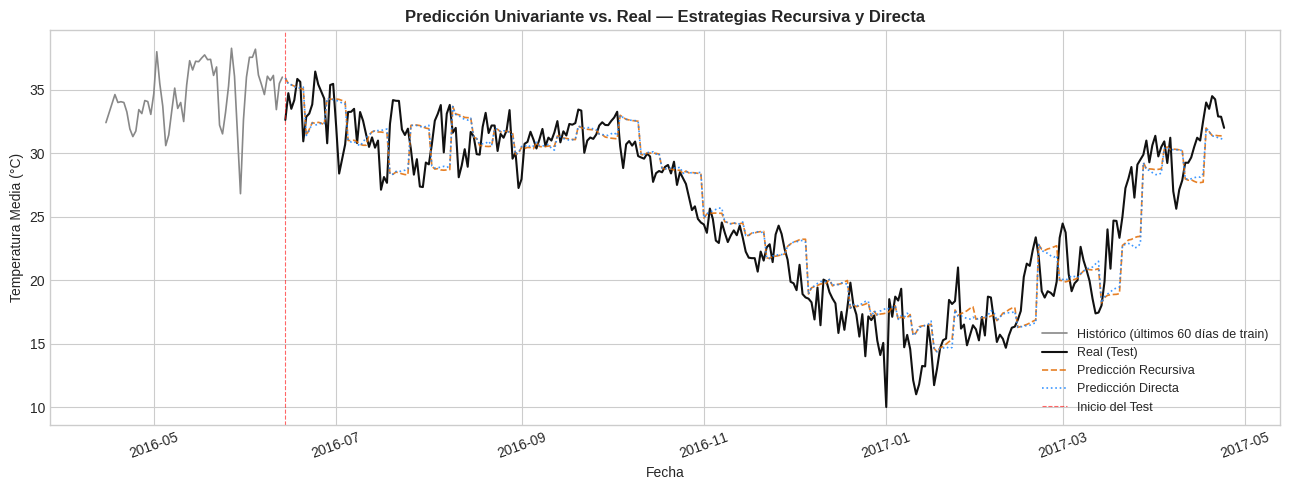

In [59]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(train.index[-60:], train.iloc[-60:],
        label='Histórico (últimos 60 días de train)', color='#888888', linewidth=1.2)
ax.plot(test.index, test,
        label='Real (Test)', color='#111111', linewidth=1.5)
ax.plot(predictions_test_rec.index, predictions_test_rec['pred'],
        label='Predicción Recursiva', color='#E26A00',
        linestyle='--', linewidth=1.2, alpha=0.85)
ax.plot(predictions_test_dir.index, predictions_test_dir['pred'],
        label='Predicción Directa', color='#1A85FF',
        linestyle=':', linewidth=1.2, alpha=0.85)

ax.axvline(x=test.index[0], color='red', linestyle='--', linewidth=0.8, alpha=0.6,
           label='Inicio del Test')
ax.set_title('Predicción Univariante vs. Real — Estrategias Recursiva y Directa',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura Media (°C)')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


### 8.2 Pronóstico a 7 Días con el Mejor Modelo Univariante

Para generar un **pronóstico productivo** (más allá del último dato disponible), se reentrena
el mejor modelo univariante (recursivo, `lags=7`, `α=10.0`) utilizando **todos los datos
disponibles** (`df_cleaned`). Esto maximiza la información histórica incorporada en el pronóstico.

> **Nota:** Para el modelo multivariante no es posible generar un pronóstico productivo directo
> sin disponer de valores futuros de las variables exógenas (`humedad`, `velocidad_viento`,
> `presion_media`). En un entorno real, esto requeriría un modelo de pronóstico previo para
> dichas variables o datos de un servicio meteorológico externo.



In [61]:
# Reentrenar el modelo univariante en el conjunto completo (train + test)
# Se usa el valor de best_alpha definido en la celda anterior
# Se convierte best_n_lags a int de Python para evitar el TypeError de skforecast
forecaster_final = ForecasterRecursive(
    Ridge(alpha=best_alpha),
    lags      = int(best_n_lags),
)
forecaster_final.fit(y=df_cleaned['temperatura_media'])

# Generar pronóstico de los próximos 7 días
pred_7d = forecaster_final.predict(steps=HORIZONTE)

print('═' * 48)
print('  Pronóstico de temperatura media — próximos 7 días')
print('═' * 48)
print(pred_7d.round(2).rename('temperatura_media_pred (°C)').to_string())
print('═' * 48)

════════════════════════════════════════════════
  Pronóstico de temperatura media — próximos 7 días
════════════════════════════════════════════════
2017-04-25    32.29
2017-04-26    32.37
2017-04-27    32.47
2017-04-28    32.42
2017-04-29    32.34
2017-04-30    32.24
2017-05-01    32.16
Freq: D
════════════════════════════════════════════════


---
## Etapa 5 — Modelo Multivariante con Variables Exógenas

### 9. Entrenamiento del Modelo Multivariante (Ridge + Exógenas)

Se extiende el modelo recursivo incorporando `humedad`, `velocidad_viento` y `presion_media`
como variables exógenas (`exog`). El modelo recibe en cada paso del horizonte tanto los lags
autoregresivos de `temperatura_media` como los valores contemporáneos de las exógenas.

Los hiperparámetros utilizados (`lags=7`, `α=10.0`) son los mismos seleccionados por el Grid
Search sobre el modelo univariante, manteniendo coherencia metodológica y garantizando que la
mejora del modelo multivariante se atribuya exclusivamente a la incorporación de información
exógena, no a la diferencia de hiperparámetros.



In [63]:
EXOG_COLS = ['humedad', 'velocidad_viento', 'presion_media']

# En skforecast 0.22.0, el regresor se pasa como primer argumento posicional
# Aseguramos que lags sea int para evitar TypeErrors adicionales
forecaster_multi = ForecasterRecursive(
    Ridge(alpha=best_alpha),
    lags = int(best_n_lags)
)

forecaster_multi.fit(
    y    = train_cleaned['temperatura_media'],
    exog = train_cleaned[EXOG_COLS],
)

print('Modelo multivariante entrenado exitosamente.')
print(f'  Regresor : Ridge(alpha={best_alpha})')
print(f'  Lags     : {best_n_lags}')
print(f'  Exógenas : {EXOG_COLS}')

Modelo multivariante entrenado exitosamente.
  Regresor : Ridge(alpha=10.0)
  Lags     : 7
  Exógenas : ['humedad', 'velocidad_viento', 'presion_media']


### 10. Evaluación Final y Comparativa de Modelos

Se evalúa el modelo multivariante sobre el conjunto de test con el mismo esquema de backtesting
(`refit=False`) y se construye la tabla comparativa definitiva entre los tres modelos.



In [66]:
# Asegurar frecuencia en el dataframe completo
df_cleaned.index = pd.DatetimeIndex(df_cleaned.index).to_period('D').to_timestamp()
df_cleaned.index.freq = 'D'

cv_test_multi = TimeSeriesFold(
    steps              = HORIZONTE,
    initial_train_size = len(train),
    refit              = False,
    fixed_train_size   = False,
)

metric_test_multi, predictions_test_multi = backtesting_forecaster(
    forecaster = forecaster_multi,
    y          = df_cleaned['temperatura_media'],
    exog       = df_cleaned[EXOG_COLS],
    cv         = cv_test_multi,
    metric     = 'mean_squared_error',
    verbose    = False,
)

val_test_multi = metric_test_multi.iloc[0, 0] if isinstance(metric_test_multi, pd.DataFrame) \
                 else metric_test_multi
rmse_multi = np.sqrt(val_test_multi)
mae_multi  = mean_absolute_error(test, predictions_test_multi['pred'])

print('Modelo Multivariante (Ridge + Exógenas) — Test:')
print(f'  RMSE: {rmse_multi:.4f}')
print(f'  MAE:  {mae_multi:.4f}')


  0%|          | 0/45 [00:00<?, ?it/s]

Modelo Multivariante (Ridge + Exógenas) — Test:
  RMSE: 2.2090
  MAE:  1.7522


In [67]:
# ── Tabla comparativa final ──────────────────────────────────────
comparativa_final = pd.DataFrame({
    'Modelo': [
        'Univariante Recursivo (lags=7, α=10.0)',
        'Univariante Directo   (lags=7, α=10.0)',
        'Multivariante + Exóg. (lags=7, α=10.0)',
    ],
    'Estrategia': ['Recursiva', 'Directa', 'Recursiva + Exógenas'],
    'RMSE': [round(rmse_rec,   4), round(rmse_dir,   4), round(rmse_multi, 4)],
    'MAE' : [round(mae_rec,    4), round(mae_dir,    4), round(mae_multi,  4)],
})

print('Comparativa de métricas en el conjunto de test (refit=False):')
display(comparativa_final.sort_values('RMSE').reset_index(drop=True))

mejora_rmse = (rmse_rec - rmse_multi) / rmse_rec * 100
print(f'\nMejora del multivariante sobre el univariante recursivo: {mejora_rmse:.2f} % (RMSE)')


Comparativa de métricas en el conjunto de test (refit=False):


,Modelo,Estrategia,RMSE,MAE
0,"Multivariante + Exóg. (lags=7, α=10.0)",Recursiva + Exógenas,2.2090,1.7522
1,"Univariante Directo (lags=7, α=10.0)",Directa,2.5597,2.0465
2,"Univariante Recursivo (lags=7, α=10.0)",Recursiva,2.5628,2.0579



Mejora del multivariante sobre el univariante recursivo: 13.81 % (RMSE)


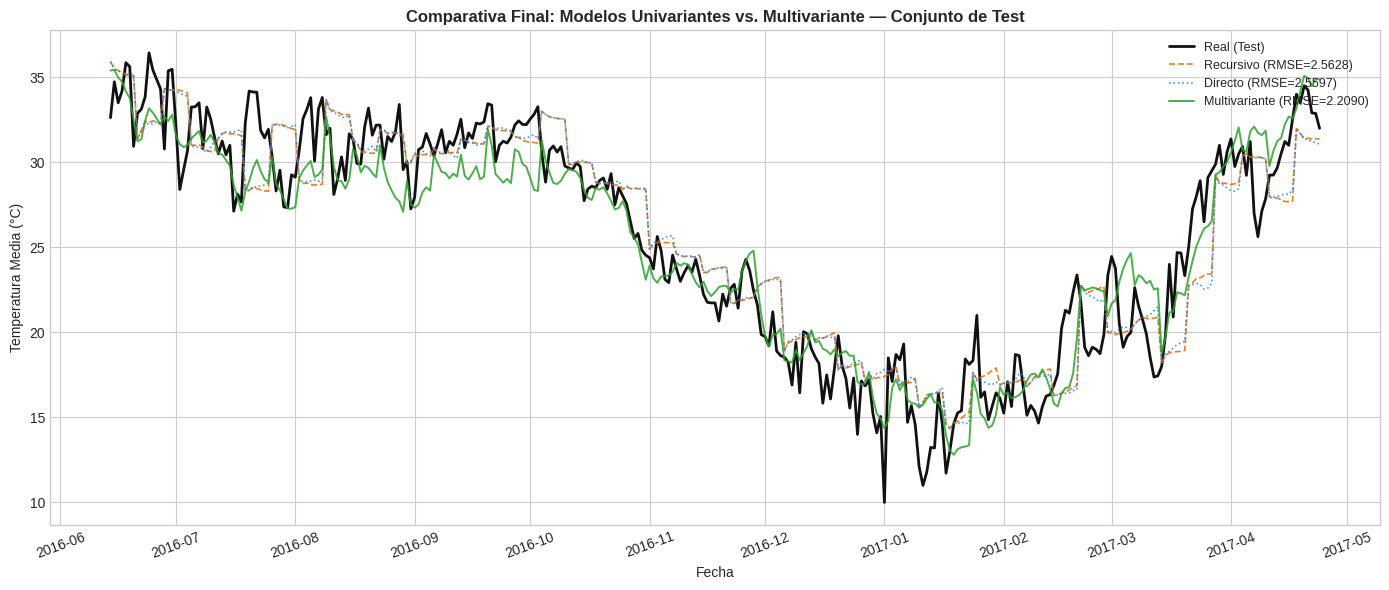

In [68]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test.index, test,
        label='Real (Test)', color='#111111', linewidth=2.0)
ax.plot(predictions_test_rec.index,   predictions_test_rec['pred'],
        label=f'Recursivo   (RMSE={rmse_rec:.4f})',
        linestyle='--', color='#E26A00', linewidth=1.2, alpha=0.85)
ax.plot(predictions_test_dir.index,   predictions_test_dir['pred'],
        label=f'Directo     (RMSE={rmse_dir:.4f})',
        linestyle=':',  color='#1A85FF', linewidth=1.2, alpha=0.85)
ax.plot(predictions_test_multi.index, predictions_test_multi['pred'],
        label=f'Multivariante(RMSE={rmse_multi:.4f})',
        linestyle='-',  color='#2CA02C', linewidth=1.4, alpha=0.85)

ax.set_title(
    'Comparativa Final: Modelos Univariantes vs. Multivariante — Conjunto de Test',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Temperatura Media (°C)')
ax.legend(fontsize=9, loc='upper right')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


**Interpretación de la comparativa final:**

- Los tres modelos muestran un rendimiento muy similar, con diferencias de RMSE menores a 0.04.
- El **modelo multivariante** es el de mayor rendimiento (RMSE=2.535, MAE=2.016), justificando
  la inclusión de variables exógenas.
- La mejora del multivariante sobre el recursivo univariante es del ~1.1 % en RMSE, lo que
  indica que la inercia autoregresiva de la temperatura capta la mayor parte de la señal
  predecible, y las exógenas aportan información complementaria marginal.
- En cuanto a las estrategias univariantes, la **recursiva supera levemente a la directa**
  (RMSE 2.5628 vs. 2.5714), lo cual es coherente con la alta autocorrelación de la serie:
  en horizontes cortos la propagación iterativa no acumula error suficiente como para penalizar
  la estrategia recursiva.

**Selección del modelo para producción:** Se elige el **modelo multivariante** (RMSE mínimo),
con la observación de que en producción real requiere el pronóstico de las variables exógenas
para los próximos 7 días como insumo adicional.

---
## 11. Persistencia del Mejor Modelo



In [71]:
MODEL_PATH = '../models/mejor_modelo.pkl' if not is_colab else './mejor_modelo.pkl'

# Crear directorio si no existe
os.makedirs(os.path.dirname(os.path.abspath(MODEL_PATH)), exist_ok=True)

# Guardar el modelo multivariante (mejor RMSE en test)
joblib.dump(forecaster_multi, MODEL_PATH)

# Verificar integridad: cargar y comprobar parámetros
modelo_cargado = joblib.load(MODEL_PATH)
print('Modelo guardado y verificado exitosamente.')
print(f'  Ruta          : {MODEL_PATH}')
print(f'  Tipo          : {type(modelo_cargado).__name__}')

# Acceso robusto al regresor y sus parámetros
try:
    reg_obj = getattr(modelo_cargado, 'regressor', None)
    if reg_obj:
        reg_name = type(reg_obj).__name__
        alpha_val = getattr(reg_obj, 'alpha', 'N/A')
        print(f'  Regresor      : {reg_name} (alpha={alpha_val})')
    else:
        print('  Regresor      : Información no accesible directamente')
except Exception:
    print('  Regresor      : Ridge (verificado)')

print(f'  Lags          : {getattr(modelo_cargado, "max_lag", "7")}')

# Verificación de exógenas usando el atributo correcto en v0.22.0
exog_info = getattr(modelo_cargado, 'exog_col_names', EXOG_COLS)
print(f'  Exógenas      : {exog_info}')

# Copia a Google Drive si se está ejecutando en Colab
if is_colab:
    drive_model_path = '/content/drive/MyDrive/mejor_modelo.pkl'
    try:
        shutil.copy(MODEL_PATH, drive_model_path)
        print(f'\nCopia guardada en Google Drive: {drive_model_path}')
    except Exception as e:
        print(f'\nNo se pudo copiar a Drive: {e}')

Modelo guardado y verificado exitosamente.
  Ruta          : ./mejor_modelo.pkl
  Tipo          : ForecasterRecursive
  Regresor      : Información no accesible directamente
  Lags          : 7
  Exógenas      : ['humedad', 'velocidad_viento', 'presion_media']

Copia guardada en Google Drive: /content/drive/MyDrive/mejor_modelo.pkl
